# Fase 3: Modelización de Churn + Segmentación

Predecir qué clientes dejarán de comprar en los próximos 90 días (Pregunta de negocio 1)
y segmentar la base para actuar de forma diferenciada (Pregunta 3).

Las preguntas se responden 1 → 3 → 2 y se presentan 1 → 2 → 3. El motivo es técnico: la
segmentación reutiliza el mismo espacio de features, el mismo `scaler` y el mismo split
temporal que el modelo de churn, así que vive en este notebook. El CLV (Pregunta 2) necesita
antes la definición de churn cerrada, porque se entrena sólo sobre quienes vuelven.

**Modelos comparados:** Logistic Regression (baseline lineal interpretable) · Random Forest ·
LightGBM · XGBoost · K-Means (segmentación).

**Validación.** Split temporal: se entrena con las 10 primeras ventanas y se evalúa con
las 6 últimas, replicando el uso real del modelo — predecir un futuro que no ha ocurrido.
La validación cruzada interna agrupa por `CustomerID` para que ninguna observación de un
mismo cliente caiga a la vez en train y validación. El test se usa **una sola vez**, para
reportar: ni el modelo ganador ni el umbral se eligen mirándolo.

**Cómo se elige el ganador.** No por quedar primero. Se compara la diferencia entre modelos
con el ruido de la propia validación cruzada —la desviación entre folds—; si cabe dentro, el
marcador no distingue y decide un criterio declarado de antemano (celda siguiente). El elegido
resulta ser además el mejor de la columna de CV, por un margen que la celda mide y que no
sobreviviría a otra semilla; en el notebook de CLV el mismo criterio elige a uno que **no**
encabeza la tabla. Que la respuesta no dependa de quién quede primero es justo lo que se le
pide. La tabla muestra media y desviación para que el empate se pueda verificar.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (GridSearchCV, StratifiedGroupKFold,
                                     cross_val_predict, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, precision_recall_curve,
                             confusion_matrix, silhouette_score)
import xgboost as xgb
import lightgbm as lgb

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))  # tfm_pipeline.py vive en src/, no junto al notebook
import tfm_pipeline as tfm

tfm.setup_notebook()

N_TRAIN_WINDOWS = 10   # las ventanas restantes son test
RANDOM_STATE = 42

# --- Criterio de selección, declarado antes de ver resultados -----------------
# Siempre sobre validación cruzada en train, nunca sobre el test:
#   1. De cada modelo se mide el ROC-AUC medio de la CV y su desviación entre folds,
#      que es el ruido de remuestreo de la propia medición.
#   2. Empatan los que queden a menos de MEDIA desviación del mejor. La tolerancia se
#      deriva del ruido medido, no se fija a mano, así que el lector puede verificarla.
#   3. Entre los empatados decide el orden de preferencia de abajo.
# El orden antepone los árboles por dos razones ajenas al rendimiento: SHAP sobre un
# árbol describe la FORMA del efecto y sobre un modelo lineal sólo reescribe el
# coeficiente, y el prototipo no depende de replicar `log1p` y el `scaler` al predecir.
# Se fija a priori para que la elección no pueda recaer luego en quien mejor quede en
# test.
FACTOR_TOLERANCIA = 0.5        # tolerancia de empate, en desviaciones típicas de la CV
PREFERENCIA = ['xgb', 'lgb', 'rf', 'lr']

## Datos, transformación y split temporal

**7 features.** Se excluyen `avg_order_value` (= `monetary / frequency`) y
`purchase_frequency_per_month` (= `frequency / (customer_age_days/30 + 1)`): ambas son
combinaciones algebraicas de features ya presentes y su colinealidad volvía ilegibles —con
signos invertidos— los coeficientes del modelo lineal, sin aportar AUC a cambio.

Cuatro de las siete tienen colas muy pesadas —la celda mide cuánto—. Se les aplica `log1p`
antes de escalar, lo que estabiliza los modelos lineales sin afectar a los de árbol,
invariantes a transformaciones monótonas.

In [2]:
data = pd.read_csv('../outputs/fase2_features/customer_features_fase2.csv', parse_dates=['observation_date'])

FEATURES = tfm.FEATURES
LOG_FEATURES = tfm.LOG_FEATURES
preprocess = tfm.preprocess   # definida una sola vez, en tfm_pipeline.py

windows = np.sort(data['observation_date'].unique())
cutoff = windows[N_TRAIN_WINDOWS]

train = data[data['observation_date'] < cutoff]
test = data[data['observation_date'] >= cutoff]

X_train, y_train, groups_train = train[FEATURES], train['churn'], train['CustomerID']
X_test, y_test = test[FEATURES], test['churn']

# El scaler se ajusta SOLO con train: el test simula datos que aún no existen.
scaler = StandardScaler().fit(preprocess(X_train))
X_train_s = scaler.transform(preprocess(X_train))
X_test_s = scaler.transform(preprocess(X_test))

# El split es TEMPORAL, no por cliente: un mismo cliente aparece en ventanas de train
# y de test, y es correcto que así sea. Lo que no puede haber es solape de fechas.
assert train.observation_date.max() < test.observation_date.min(), \
    "el split temporal se solapa"

print(f"Features ({len(FEATURES)}): {', '.join(FEATURES)}\n")
print(f"Train: {len(train):,} obs · ventanas {pd.Timestamp(windows[0]).date()} "
      f"a {pd.Timestamp(windows[N_TRAIN_WINDOWS-1]).date()} · churn {y_train.mean():.1%}")
print(f"Test : {len(test):,} obs · ventanas {pd.Timestamp(cutoff).date()} "
      f"a {pd.Timestamp(windows[-1]).date()} · churn {y_test.mean():.1%}")
print("\nAsimetría y peso de la cola (train):")
print(f"  {'':28s} {'skew':>8s} {'-> log1p':>9s} {'p99/mediana':>12s} {'máx/mediana':>12s}")
for c in LOG_FEATURES:
    med = X_train[c].median()
    print(f"  {c:28s} {X_train[c].skew():8.1f} {np.log1p(X_train[c]).skew():9.2f} "
          f"{X_train[c].quantile(.99)/med:11.0f}x {X_train[c].max()/med:11.0f}x")

Features (7): recency_days, frequency, monetary, return_rate, customer_age_days, avg_items_per_transaction, unique_products

Train: 30,975 obs · ventanas 2010-06-01 a 2011-03-01 · churn 52.4%
Test : 17,419 obs · ventanas 2011-04-01 a 2011-09-01 · churn 48.8%

Asimetría y peso de la cola (train):
                                   skew  -> log1p  p99/mediana  máx/mediana
  frequency                         9.6      1.54          10x          63x
  monetary                         19.2      0.31          25x         373x
  avg_items_per_transaction        44.1     -0.54           9x         546x
  unique_products                   6.4     -0.33           9x          43x


## Correlaciones y selección de variables

La matriz responde a una pregunta concreta: **¿sobra alguna variable?** Conviene mirarla en el
espacio que ve el modelo —`log1p` y estandarizado—, que es donde la colinealidad afecta a los
coeficientes.

Tres diagnósticos, en orden de autoridad creciente:

| Diagnóstico | Qué mide | Umbral de alarma |
|---|---|---|
| Correlación por pares | Relación lineal entre dos variables | No hay uno: correlacionadas no es lo mismo que redundantes |
| VIF y número de condición | Cuánto de cada variable explican **todas** las demás | VIF > 10 · condición > 30 |
| **Ablación** | Qué pierde el modelo si se quita | Ninguna: es la medida directa |

La correlación por sí sola no justifica eliminar nada, y por eso el criterio de exclusión de la
Fase 2 fue la **redundancia algebraica exacta** —`avg_order_value` no es una variable
correlacionada con otras, *es* otras dos reescritas— y no un umbral sobre esta matriz.

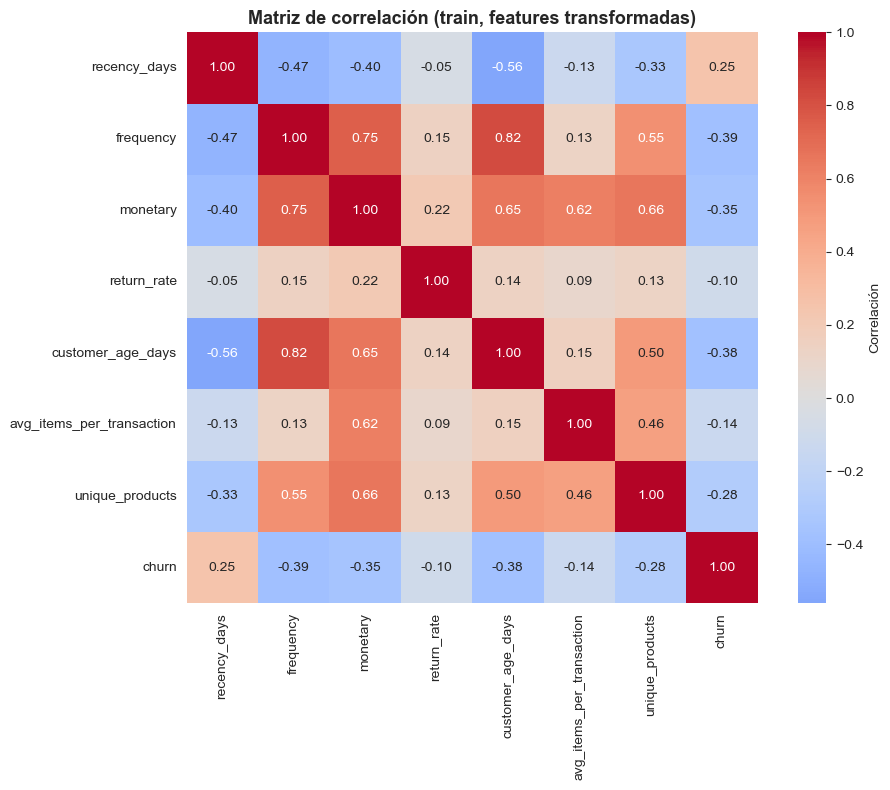

frequency                   -0.388
customer_age_days           -0.375
monetary                    -0.354
unique_products             -0.284
recency_days                 0.250
avg_items_per_transaction   -0.137
return_rate                 -0.097


In [3]:
corr = preprocess(train[FEATURES]).assign(churn=y_train.values).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de correlación (train, features transformadas)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(corr['churn'].drop('churn').sort_values(key=abs, ascending=False).round(3).to_string())

In [4]:
# --- Colinealidad global ------------------------------------------------------
corr_features = pd.DataFrame(X_train_s, columns=FEATURES).corr()
pares = (corr_features.where(np.triu(np.ones(corr_features.shape), 1).astype(bool))
         .stack().sort_values(key=abs, ascending=False))
print('Pares más correlacionados:')
for (a, b), v in pares.head(4).items():
    print(f"  {a:26s} ~ {b:26s} {v:+.3f}")

# VIF_i = 1 / (1 - R²) de regresar cada variable contra TODAS las demás. Es el diagnóstico
# que la tabla de arriba anuncia, así que se calcula aquí en vez de darlo por sabido.
def vif(X):
    from sklearn.linear_model import LinearRegression
    return pd.Series({c: 1 / (1 - LinearRegression()
                              .fit(np.delete(X, i, axis=1), X[:, i])
                              .score(np.delete(X, i, axis=1), X[:, i]))
                      for i, c in enumerate(FEATURES)}).sort_values(ascending=False)


VIF = vif(X_train_s)
print(f"\nVIF (alarma > 10):  máx {VIF.max():.1f} en {VIF.index[0]}  ·  "
      f"{', '.join(f'{c} {v:.1f}' for c, v in VIF.items())}")

COND = np.linalg.cond(X_train_s)
print(f"Número de condición de la matriz de diseño: {COND:.1f}  "
      f"(>30 colinealidad moderada, >100 severa)")

# --- Ablación: la medida que decide -------------------------------------------
# La correlación sugiere; lo que zanja es cuánto pierde el modelo al quitar la variable.
cv_abl = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def auc_cv(cols):
    X_ablacion = StandardScaler().fit_transform(
        preprocess(train[cols].copy(), [c for c in LOG_FEATURES if c in cols]))
    return cross_val_score(LogisticRegression(C=0.001, max_iter=1000), X_ablacion, y_train,
                           groups=groups_train, cv=cv_abl, scoring='roc_auc',
                           n_jobs=-1).mean()


auc_base = auc_cv(FEATURES)
ablacion = pd.Series({f: auc_cv([c for c in FEATURES if c != f]) for f in FEATURES})
ablacion = (ablacion - auc_base).sort_values()

print(f"\nAblación — CV ROC-AUC con las {len(FEATURES)} features: {auc_base:.4f}")
print('Coste de quitar cada una:')
for f, delta in ablacion.items():
    print(f"  sin {f:28s} {auc_base + delta:.4f}   ({delta:+.4f})")

# `ablacion` está ordenada de forma ascendente, así que el primer elemento es el delta
# MÁS NEGATIVO: la variable cuya eliminación más AUC cuesta, es decir, la más valiosa.
MAS_VALIOSA, MAS_PRESCINDIBLE = ablacion.index[0], ablacion.index[-1]
print(f"\nNinguna variable estorba: quitar la más prescindible ({MAS_PRESCINDIBLE}) cuesta "
      f"{-ablacion.iloc[-1]:.4f} de AUC y la más")
print(f"valiosa ({MAS_VALIOSA}) sólo aporta {-ablacion.iloc[0]:.4f}. Con un VIF máximo de "
      f"{VIF.max():.1f} y")
print(f"número de condición de {COND:.0f}, no hay caso para eliminar nada más: eliminar sólo resta.")

Pares más correlacionados:
  frequency                  ~ customer_age_days          +0.817
  frequency                  ~ monetary                   +0.753
  monetary                   ~ unique_products            +0.661
  monetary                   ~ customer_age_days          +0.655

VIF (alarma > 10):  máx 6.7 en monetary  ·  monetary 6.7, frequency 5.7, customer_age_days 3.5, avg_items_per_transaction 2.9, unique_products 1.9, recency_days 1.5, return_rate 1.1
Número de condición de la matriz de diseño: 6.6  (>30 colinealidad moderada, >100 severa)



Ablación — CV ROC-AUC con las 7 features: 0.7325
Coste de quitar cada una:
  sin frequency                    0.7292   (-0.0033)
  sin customer_age_days            0.7310   (-0.0015)
  sin recency_days                 0.7315   (-0.0010)
  sin unique_products              0.7316   (-0.0009)
  sin monetary                     0.7318   (-0.0007)
  sin return_rate                  0.7320   (-0.0005)
  sin avg_items_per_transaction    0.7323   (-0.0002)

Ninguna variable estorba: quitar la más prescindible (avg_items_per_transaction) cuesta 0.0002 de AUC y la más
valiosa (frequency) sólo aporta 0.0033. Con un VIF máximo de 6.7 y
número de condición de 7, no hay caso para eliminar nada más: eliminar sólo resta.


## Grid Search

`StratifiedGroupKFold` mantiene la proporción de churn en cada fold y garantiza que todas
las observaciones de un mismo cliente caigan en el mismo fold. Sobre esa validación cruzada
se ajustan los hiperparámetros de los cuatro modelos con `roc_auc` como métrica.

### Cómo se elige el modelo — por CV, nunca por test

1. **El ruido de la medición** es la desviación típica del ROC-AUC entre folds (≈ ±0,0098
   de media).
2. **La tolerancia de empate se deriva de ese ruido** (0,5 sd ≈ 0,0049), no se fija a mano
   — así el lector puede verificarla. Empatan todos los modelos cuyo CV ROC-AUC quede a
   menos de esa distancia del mejor.
3. **Entre los empatados decide un orden de preferencia declarado antes de calcular la
   tabla:** XGBoost → LightGBM → Random Forest → Regresión logística. Antepone los árboles
   por dos razones ajenas al rendimiento: SHAP sobre un árbol describe la *forma* del efecto
   (sobre un modelo lineal solo reescribe el coeficiente), y el prototipo no depende de
   replicar `log1p` y el `scaler` en el momento de predecir.

Esa independencia respecto del resultado es lo que hace legítimo el criterio: si el primer
puesto de la CV hubiera caído en cualquiera de los otros modelos empatados, la elección
habría sido la misma. Elegir *a posteriori* al que quedó arriba sería quedarse con el
ganador de un sorteo y presentarlo como el mejor.

**En estos datos los cuatro modelos empatan** (rango 0,0031 = 0,32 sd) y el criterio
selecciona **XGBoost**. Además encabeza la columna de CV, pero solo por 0,0003 sobre el
segundo (0,03 sd, ~3 % del ruido de la propia medición): ese primer puesto no separa dos
rendimientos, separa dos medidas del mismo número, y no sobreviviría a otra semilla de
remuestreo. No es la razón por la que se elige.

La celda calcula estos valores y los imprime como resumen para poder verificarlos.

In [5]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, grid, name):
    """Ajusta hiperparámetros y reporta la media de CV junto a su ruido entre folds."""
    search = GridSearchCV(estimator, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    search.fit(X_train_s, y_train, groups=groups_train)
    sd = search.cv_results_['std_test_score'][search.best_index_]
    print(f"{name:22s} CV ROC-AUC={search.best_score_:.4f} ± {sd:.4f}  {search.best_params_}")
    return search

grids = {}
# solver='liblinear': con lbfgs la búsqueda de línea interna desborda numéricamente
# (advertencias de overflow) aunque converja; liblinear da el mismo AUC sin ruido.
grids['lr'] = tune(LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE),
                   {'C': [0.001, 0.01, 0.1, 1, 10]}, 'Logistic Regression')
grids['rf'] = tune(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                   {'max_depth': [5, 10, 15], 'min_samples_split': [5, 10], 'n_estimators': [50, 100]},
                   'Random Forest')
grids['lgb'] = tune(lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
                    {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [50, 100]},
                    'LightGBM')
grids['xgb'] = tune(xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                    {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [50, 100]},
                    'XGBoost')

models = {k: g.best_estimator_ for k, g in grids.items()}

# --- Selección del modelo: por CV, nunca por test -----------------------------
# El razonamiento está en la celda de texto anterior. Aquí solo se calculan las cifras
# que lo sostienen: el ruido de la CV, la tolerancia de empate derivada de él, y el
# modelo que gana el orden de preferencia declarado a priori (PREFERENCIA).
SD_CV = {k: float(g.cv_results_['std_test_score'][g.best_index_]) for k, g in grids.items()}
RUIDO_CV = float(np.mean(list(SD_CV.values())))
TOLERANCIA_EMPATE = FACTOR_TOLERANCIA * RUIDO_CV

mejor_cv = max(g.best_score_ for g in grids.values())
rango = mejor_cv - min(g.best_score_ for g in grids.values())
segundo_cv = sorted((g.best_score_ for g in grids.values()), reverse=True)[1]
ventaja_sd = (mejor_cv - segundo_cv) / RUIDO_CV
empatados = [k for k in PREFERENCIA if grids[k].best_score_ >= mejor_cv - TOLERANCIA_EMPATE]
BEST = empatados[0]

print(f"\nRuido de la CV (sd media entre folds)   ±{RUIDO_CV:.4f}")
print(f"Rango mejor-peor modelo                {rango:.4f}  = {rango / RUIDO_CV:.2f} sd")
print(f"Tolerancia de empate ({FACTOR_TOLERANCIA} sd)            {TOLERANCIA_EMPATE:.4f}")
print(f"Empatan dentro de tolerancia           {', '.join(empatados)}")
print(f"Modelo seleccionado                    {BEST}  (1o del orden de preferencia declarado)")
print(f"Ventaja del 1o de CV sobre el 2o        {mejor_cv - segundo_cv:.4f}  = {ventaja_sd:.2f} sd")

Logistic Regression    CV ROC-AUC=0.7325 ± 0.0102  {'C': 0.001}


Random Forest          CV ROC-AUC=0.7353 ± 0.0102  {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}


LightGBM               CV ROC-AUC=0.7352 ± 0.0093  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


XGBoost                CV ROC-AUC=0.7356 ± 0.0095  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Ruido de la CV (sd media entre folds)   ±0.0098
Rango mejor-peor modelo                0.0031  = 0.32 sd
Tolerancia de empate (0.5 sd)            0.0049
Empatan dentro de tolerancia           xgb, lgb, rf, lr
Modelo seleccionado                    xgb  (1o del orden de preferencia declarado)
Ventaja del 1o de CV sobre el 2o        0.0003  = 0.03 sd


## Evaluación en el test temporal

El modelo ya está elegido por validación cruzada. Lo que sigue es la medición sobre las
6 ventanas no vistas (17.419 observaciones): **se reporta, no se usa para decidir**.

### Cómo leer la tabla

- La columna `± sd (folds)` es la que permite verificar la selección. Sin ella, la tabla
  invita a leer el máximo de una columna de test como «el mejor modelo» — justo el error
  que todo el esquema de validación existe para evitar.
- El rango entre modelos es 0,002 en test y 0,0031 en CV, frente a un ruido entre folds de
  ±0,0098. **Las cuatro filas describen el mismo rendimiento medido cuatro veces**, no
  cuatro rendimientos distintos.
- El modelo marcado (`*`) encabeza la columna de CV —por 0,03 sd sobre el segundo— y en
  test comparte el máximo con otros dos. No está marcado por ninguna de esas dos cosas,
  sino porque gana el criterio declarado antes de calcular la tabla. La distinción importa:
  un primer puesto que se decide por tres diezmilésimas no sobrevive a otra semilla de
  remuestreo.

### El empate es, en sí mismo, un resultado

La señal de las variables RFM está agotada y la relación es prácticamente lineal, así que el
gradient boosting no encuentra estructura adicional que explotar. La Fase 4 lo verifica con
SHAP en lugar de suponerlo — y ahí el modelo de árbol paga su elección: puede describir la
*forma* del efecto de cada variable, algo que un modelo lineal no puede hacer aunque esa
forma esté en los datos.

In [6]:
NAMES = {'lr': 'Logistic Regression', 'rf': 'Random Forest', 'lgb': 'LightGBM', 'xgb': 'XGBoost'}
proba = {k: m.predict_proba(X_test_s)[:, 1] for k, m in models.items()}

results = pd.DataFrame([{
    'Modelo': NAMES[k] + (' *' if k == BEST else ''),
    'CV ROC-AUC': round(grids[k].best_score_, 4),
    '± sd (folds)': round(SD_CV[k], 4),
    'Test ROC-AUC': round(roc_auc_score(y_test, p), 3),
    'Test PR-AUC': round(average_precision_score(y_test, p), 3),
} for k, p in proba.items()])

print(results.to_string(index=False))
print("\n* elegido por el criterio declarado sobre la CV; las métricas de test no intervienen.")
print(f"\nBaseline «marcar a todos»: Precision={y_test.mean():.3f} · Recall=1.000 · "
      f"F1={2*y_test.mean()/(1+y_test.mean()):.3f}")

# Solo la primera columna decide; las de test se reportan. Se dice explícito porque la
# tabla invita a leer el máximo de una columna de test como «el mejor modelo».
print("\nQuién encabeza cada columna:")
for col, papel in [('CV ROC-AUC', 'ELIGE'), ('Test ROC-AUC', 'reporta'), ('Test PR-AUC', 'reporta')]:
    lideres = results.loc[results[col] == results[col].max(), 'Modelo'].str.replace(' *', '', regex=False)
    print(f"  {col:13s} ({papel:7s})  {' = '.join(lideres)}")

rango_test = results['Test ROC-AUC'].max() - results['Test ROC-AUC'].min()
empatan_test = int((results['Test ROC-AUC'] == results['Test ROC-AUC'].max()).sum())
print(f"\nRango en test {rango_test:.3f}  ·  rango en CV {rango:.4f}  ·  ruido entre folds "
      f"±{RUIDO_CV:.4f}  ·  {empatan_test}/4 empatan en test  ·  ventaja 1o CV = {ventaja_sd:.2f} sd")

             Modelo  CV ROC-AUC  ± sd (folds)  Test ROC-AUC  Test PR-AUC
Logistic Regression      0.7325        0.0102         0.747        0.693
      Random Forest      0.7353        0.0102         0.749        0.692
           LightGBM      0.7352        0.0093         0.749        0.695
          XGBoost *      0.7356        0.0095         0.749        0.693

* elegido por el criterio declarado sobre la CV; las métricas de test no intervienen.

Baseline «marcar a todos»: Precision=0.488 · Recall=1.000 · F1=0.656

Quién encabeza cada columna:
  CV ROC-AUC    (ELIGE  )  XGBoost
  Test ROC-AUC  (reporta)  Random Forest = LightGBM = XGBoost
  Test PR-AUC   (reporta)  LightGBM

Rango en test 0.002  ·  rango en CV 0.0031  ·  ruido entre folds ±0.0098  ·  3/4 empatan en test  ·  ventaja 1o CV = 0.03 sd


## Selección del umbral

El umbral se fija donde **F1 es máximo sobre las predicciones out-of-fold de la validación
cruzada en train**: el mejor equilibrio entre no molestar a clientes sanos (precision) y no
dejar escapar a los que se van (recall), sin inventar una matriz de costes que la empresa no
ha declarado.

Es importante que salga de train y no del test: elegir el umbral sobre el mismo conjunto con
el que después se reporta precision y recall infla ambas métricas. Con el umbral fijado
*a ciegas* respecto al test, las cifras del test son una estimación honesta de lo que rendiría
en producción.

Es el umbral que usan todas las fases posteriores.

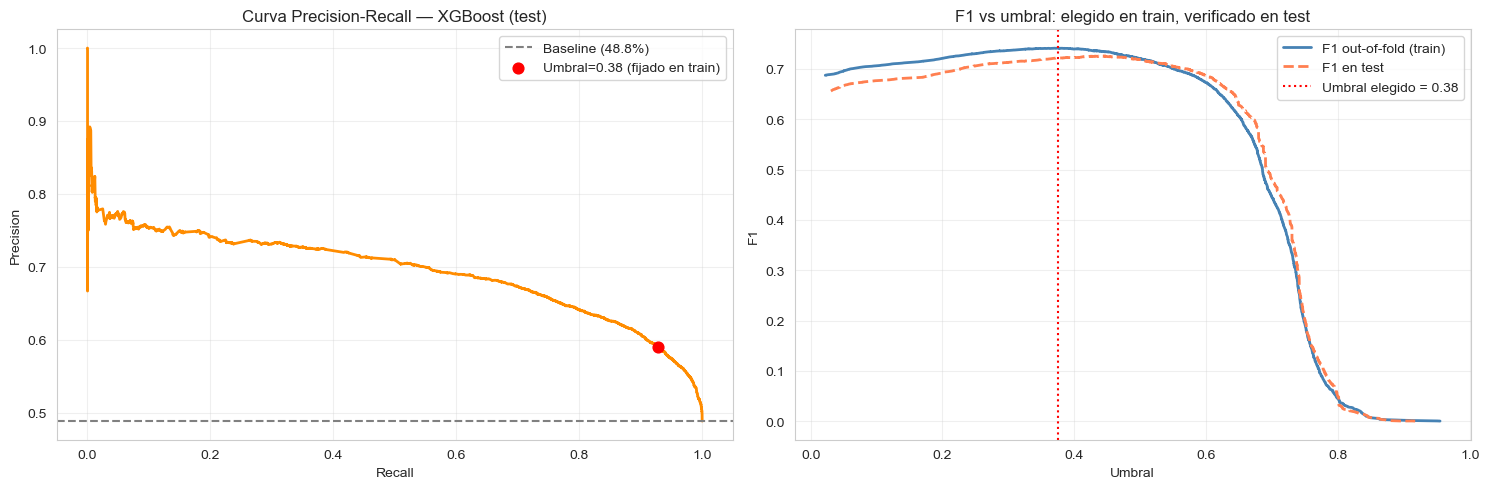

UMBRAL DE PRODUCCIÓN = 0.375  (máximo F1 out-of-fold en train)
  F1 out-of-fold (train) 0.742  ->  F1 en test 0.722
  Precision 0.590 · Recall 0.928
  De cada 100 clientes marcados en riesgo, 59 se iban de verdad.
  Detecta 93 de cada 100 clientes que efectivamente se van.
  VP 7,892 · FP 5,476 · FN 614 · VN 3,437


In [7]:
# Predicciones out-of-fold sobre train: cada observación se predice con un modelo
# que no la vio. Es la mejor estimación del comportamiento fuera de muestra sin tocar el test.
oof = cross_val_predict(clone(models[BEST]), X_train_s, y_train, groups=groups_train,
                        cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

prec_oof, rec_oof, thr_oof = precision_recall_curve(y_train, oof)
f1_oof = 2 * prec_oof * rec_oof / (prec_oof + rec_oof + 1e-12)
THRESHOLD = float(thr_oof[int(np.argmax(f1_oof[:-1]))])

# El test se evalúa con el umbral ya fijado.
p_best = proba[BEST]
precisions, recalls, thresholds = precision_recall_curve(y_test, p_best)
f1_curve = 2 * precisions * recalls / (precisions + recalls + 1e-12)
idx_test = int(np.argmin(np.abs(thresholds - THRESHOLD)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(recalls, precisions, color='darkorange', lw=2)
axes[0].axhline(y_test.mean(), color='gray', ls='--', label=f'Baseline ({y_test.mean():.1%})')
axes[0].scatter(recalls[idx_test], precisions[idx_test], color='red', zorder=5, s=60,
                label=f'Umbral={THRESHOLD:.2f} (fijado en train)')
axes[0].set(xlabel='Recall', ylabel='Precision', title=f'Curva Precision-Recall — {NAMES[BEST]} (test)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thr_oof, f1_oof[:-1], label='F1 out-of-fold (train)', lw=2, color='steelblue')
axes[1].plot(thresholds, f1_curve[:-1], label='F1 en test', lw=2, ls='--', color='coral')
axes[1].axvline(THRESHOLD, color='red', ls=':', label=f'Umbral elegido = {THRESHOLD:.2f}')
axes[1].set(xlabel='Umbral', ylabel='F1', title='F1 vs umbral: elegido en train, verificado en test')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

y_pred = (p_best >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
prec, rec = precision_score(y_test, y_pred), recall_score(y_test, y_pred)
F1_TEST = f1_score(y_test, y_pred)

print(f"UMBRAL DE PRODUCCIÓN = {THRESHOLD:.3f}  (máximo F1 out-of-fold en train)")
print(f"  F1 out-of-fold (train) {f1_oof.max():.3f}  ->  F1 en test {F1_TEST:.3f}")
print(f"  Precision {prec:.3f} · Recall {rec:.3f}")
print(f"  De cada 100 clientes marcados en riesgo, {prec*100:.0f} se iban de verdad.")
print(f"  Detecta {rec*100:.0f} de cada 100 clientes que efectivamente se van.")
print(f"  VP {tp:,} · FP {fp:,} · FN {fn:,} · VN {tn:,}")

## Priorización con capacidad limitada

El umbral responde *«¿este cliente está en riesgo?»*. El equipo de retención tiene otra
pregunta: *«sólo puedo contactar al 10% de la base este mes, ¿a quién?»*. Eso es un problema
de **ordenación**, no de clasificación, y admite dos criterios que no coinciden:

| Criterio de orden | Optimiza | Riesgo |
|---|---|---|
| `P(churn)` | Acertar en el máximo de clientes | Llena la campaña de clientes que se van pero apenas gastan |
| `P(churn) × gasto` | Proteger el máximo de libras | Baja la tasa de acierto: los clientes valiosos son más fieles |

La elección depende de si la campaña se mide en clientes retenidos o en ingresos protegidos
— y en retail el segundo objetivo es el que la financia. Se evalúan ambos criterios en toda
la rejilla de capacidades porque **depende de ella**: es mayor con presupuestos escasos —el
régimen real de un equipo de retención— y se anula cuando se puede contactar a todo el mundo.
La celda localiza el máximo en vez de suponer que está en el extremo.

La unidad de la tabla son **observaciones cliente-ventana**, no clientes distintos.

In [8]:
rank_base = pd.DataFrame({
    'churn_real': y_test.values,
    'p_churn': p_best,
    'monetary': X_test['monetary'].values,
})
valor_total_perdido = rank_base.loc[rank_base.churn_real == 1, 'monetary'].sum()
capacidades = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]


def evaluar_ranking(df, criterio, etiqueta):
    df = df.sort_values(criterio, ascending=False)
    filas = []
    for k in capacidades:
        top = df.head(int(len(df) * k))
        filas.append({
            'Estrategia': etiqueta,
            'Capacidad': f"{k:.0%}",
            'Observaciones': len(top),
            'Precision@K': round(top.churn_real.mean(), 3),
            'Recall@K': round(top.churn_real.sum() / df.churn_real.sum(), 3),
            '% valor protegido': round(
                top.loc[top.churn_real == 1, 'monetary'].sum() / valor_total_perdido, 3),
        })
    return pd.DataFrame(filas)


rank_base['valor_esperado'] = rank_base['p_churn'] * rank_base['monetary']
por_riesgo = evaluar_ranking(rank_base, 'p_churn', 'Por riesgo')
por_valor = evaluar_ranking(rank_base, 'valor_esperado', 'Por valor esperado')
capacidad_df = pd.concat([por_riesgo, por_valor], ignore_index=True)

print(capacidad_df.pivot(index='Capacidad', columns='Estrategia',
                         values=['Precision@K', '% valor protegido'])
      .reindex([f"{k:.0%}" for k in capacidades]).to_string())

# El denominador, explícito: todo «% valor protegido» es una fracción DE ESTO.
# Es valor realizado (gasto observado de quien efectivamente abandonó), no valor
# predicho: no debe mezclarse con el total de la matriz de prioridad de la Fase 3b,
# que suma riesgo predicho x CLV predicho sobre toda la base.
print(f"\nDenominador — valor realmente perdido en el test: £{valor_total_perdido:,.0f}")
print(f"  = suma de `monetary` (gasto de los 6 meses previos) de las "
      f"{int(rank_base.churn_real.sum()):,} observaciones que SI abandonaron.")

# Caso económico en libras: el % de valor protegido no se lee solo, hace falta
# saber cuántas libras y cuántos contactos representa.
print("\nValor que entra en la lista de contactos, por capacidad de campaña:")
print(f"  {'Cap.':>5}  {'Contactos':>9}  {'Por valor esperado':>22}  {'Por riesgo':>20}  {'Ventaja':>8}")
for k in ['5%', '10%', '20%', '50%']:
    fv = por_valor[por_valor.Capacidad == k].iloc[0]
    fr = por_riesgo[por_riesgo.Capacidad == k].iloc[0]
    lv = fv['% valor protegido'] * valor_total_perdido
    lr = fr['% valor protegido'] * valor_total_perdido
    print(f"  {k:>5}  {fv['Observaciones']:>9,}  "
          f"£{lv:>12,.0f} ({fv['% valor protegido']:>5.1%})  "
          f"£{lr:>11,.0f} ({fr['% valor protegido']:>4.1%})  "
          f"{fv['% valor protegido'] / fr['% valor protegido']:>7.1f}x")

           Precision@K                    % valor protegido                   
Estrategia  Por riesgo Por valor esperado        Por riesgo Por valor esperado
Capacidad                                                                     
5%               0.753              0.382             0.099              0.304
10%              0.747              0.368             0.120              0.390
15%              0.735              0.359             0.140              0.455
20%              0.731              0.362             0.165              0.517
30%              0.716              0.366             0.240              0.612
40%              0.694              0.371             0.329              0.699
50%              0.676              0.389             0.451              0.777

Denominador — valor realmente perdido en el test: £5,582,966
  = suma de `monetary` (gasto de los 6 meses previos) de las 8,506 observaciones que SI abandonaron.

Valor que entra en la lista de contactos, por 

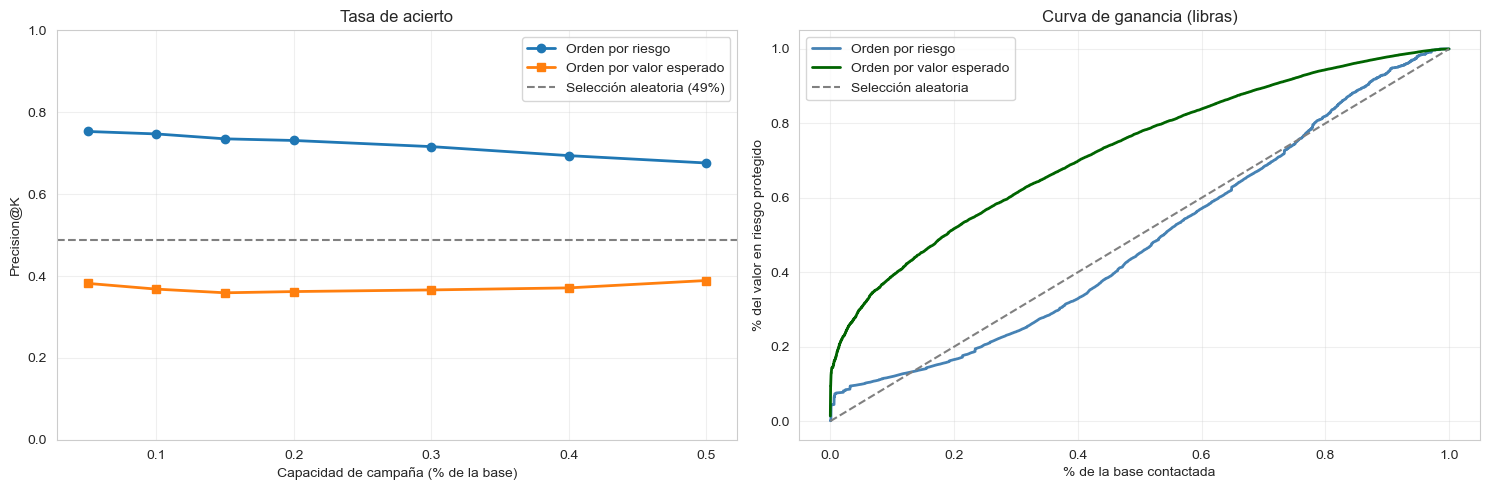

Contactando al 10% de la base (1,741 observaciones cliente-ventana):
  Orden por riesgo         -> 75% de acierto, protege 12% de las libras en riesgo
  Orden por valor esperado -> 37% de acierto, protege 39% de las libras en riesgo
  Aleatorio                -> 49% de acierto, protege 10%

Ordenar por valor esperado multiplica por 3.3 las libras protegidas.

Y depende de la capacidad, con el máximo en el 10% (3.3x) — no en el extremo:
  5%: 3.1x  ·  10%: 3.3x  ·  15%: 3.2x  ·  20%: 3.1x  ·  30%: 2.6x  ·  40%: 2.1x  ·  50%: 1.7x
Por debajo de esa capacidad la ventaja baja (3.1x al 5%): una lista tan corta la llenan
los mismos clientes extremos ordene como ordene. Por encima, decae hasta anularse.
Con capacidad ilimitada ambos criterios convergen: contactar a todos protege todo.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = [float(c.strip('%')) / 100 for c in por_riesgo['Capacidad']]

axes[0].plot(x, por_riesgo['Precision@K'], marker='o', lw=2, label='Orden por riesgo')
axes[0].plot(x, por_valor['Precision@K'], marker='s', lw=2, label='Orden por valor esperado')
axes[0].axhline(y_test.mean(), color='gray', ls='--', label=f'Selección aleatoria ({y_test.mean():.0%})')
axes[0].set(xlabel='Capacidad de campaña (% de la base)', ylabel='Precision@K',
            title='Tasa de acierto', ylim=(0, 1))
axes[0].legend(); axes[0].grid(alpha=0.3)

for criterio, etiqueta, color in [('p_churn', 'Orden por riesgo', 'steelblue'),
                                  ('valor_esperado', 'Orden por valor esperado', 'darkgreen')]:
    orden = rank_base.sort_values(criterio, ascending=False)
    cum = np.where(orden.churn_real == 1, orden.monetary, 0).cumsum() / valor_total_perdido
    axes[1].plot(np.arange(1, len(orden) + 1) / len(orden), cum, lw=2, label=etiqueta, color=color)
axes[1].plot([0, 1], [0, 1], ls='--', color='gray', label='Selección aleatoria')
axes[1].set(xlabel='% de la base contactada', ylabel='% del valor en riesgo protegido',
            title='Curva de ganancia (libras)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Se ilustra con la MISMA capacidad que plantea la pregunta de negocio de arriba.
CAPACIDAD_ILUSTRATIVA = '10%'
fila_riesgo = por_riesgo[por_riesgo.Capacidad == CAPACIDAD_ILUSTRATIVA].iloc[0]
fila_valor = por_valor[por_valor.Capacidad == CAPACIDAD_ILUSTRATIVA].iloc[0]
VENTAJA_VALOR = fila_valor['% valor protegido'] / fila_riesgo['% valor protegido']

print(f"Contactando al {CAPACIDAD_ILUSTRATIVA} de la base "
      f"({fila_riesgo['Observaciones']:,} observaciones cliente-ventana):")
print(f"  Orden por riesgo         -> {fila_riesgo['Precision@K']:.0%} de acierto, "
      f"protege {fila_riesgo['% valor protegido']:.0%} de las libras en riesgo")
print(f"  Orden por valor esperado -> {fila_valor['Precision@K']:.0%} de acierto, "
      f"protege {fila_valor['% valor protegido']:.0%} de las libras en riesgo")
print(f"  Aleatorio                -> {y_test.mean():.0%} de acierto, protege "
      f"{CAPACIDAD_ILUSTRATIVA}")
print(f"\nOrdenar por valor esperado multiplica por {VENTAJA_VALOR:.1f} las libras protegidas.")

# La ventaja no es una constante: depende de la capacidad y crece cuanto más escasa es.
ventajas = (por_valor.set_index('Capacidad')['% valor protegido'] /
            por_riesgo.set_index('Capacidad')['% valor protegido'])
print(f"\nY depende de la capacidad, con el máximo en el {ventajas.idxmax()} "
      f"({ventajas.max():.1f}x) — no en el extremo:")
print('  ' + '  ·  '.join(f"{c}: {v:.1f}x" for c, v in ventajas.items()))
print(f"Por debajo de esa capacidad la ventaja baja ({ventajas.iloc[0]:.1f}x al "
      f"{ventajas.index[0]}): una lista tan corta la llenan\nlos mismos clientes extremos "
      "ordene como ordene. Por encima, decae hasta anularse.")
print("Con capacidad ilimitada ambos criterios convergen: contactar a todos protege todo.")

## Segmentación K-Means

Responde la Pregunta 3. Se ajusta sobre train con las mismas features transformadas
y se aplica a toda la base.

**Sobre la elección de *k*.** El *silhouette* favorece *k* = 2, pero ese corte sólo separa
«compra mucho» de «compra poco»: no distingue a un cliente valioso que se está enfriando de
otro que nunca ha repetido, y esos dos casos piden campañas opuestas. Se elige *k* = 5 por
criterio de negocio, y se declara como tal en lugar de presentarlo como un óptimo
estadístico.

**Sobre el peso económico de cada segmento.** `monetary` es el gasto de una ventana de 6
meses, y cada cliente aparece en varias ventanas solapadas: sumarlo sobre todas ellas contaría
la misma transacción hasta seis veces. Para el peso económico se asigna a cada cliente su
cluster mayoritario y se suma su gasto **real** en el histórico completo, sin duplicar.

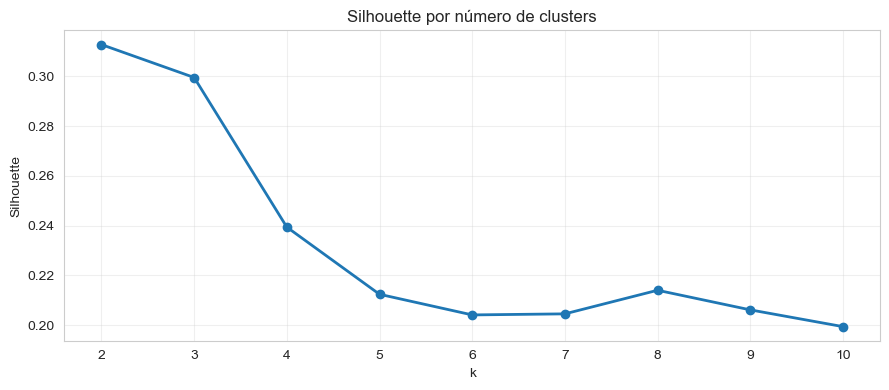

k = 5 (silhouette 0.212); argmax global en k=2 (0.313) — descartado por criterio de negocio



         observaciones  churn_rate  recency  frequency  monetary  ticket  return_rate  clientes  revenue_real  % revenue
cluster                                                                                                                 
0                 8761        0.73    94.29       1.21    174.78  148.00         0.02      1181      583744.0        3.6
1                14563        0.65    86.42       1.27    546.59  450.32         0.00      1909     2363606.0       14.5
2                 6941        0.14    20.34       9.04   5587.57  616.08         0.19       506     9384835.0       57.6
3                11519        0.38    33.75       3.19   1023.87  342.64         0.08       911     2766714.0       17.0
4                 6610        0.55    83.85       1.69    869.35  563.51         0.46       742     1199372.0        7.4

Revenue real repartido: £16,298,271 de £16,648,292 del dataset limpio (97.9%), contado una sola vez por cliente.
El 2.1% restante son 691 clientes que n

In [10]:
sil = {}
for k in range(2, 11):
    km_prueba = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train_s)
    sil[k] = silhouette_score(X_train_s, km_prueba.labels_, sample_size=10000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(sil), list(sil.values()), marker='o', lw=2)
ax.set(xlabel='k', ylabel='Silhouette', title='Silhouette por número de clusters')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10).fit(X_train_s)
data['cluster'] = kmeans.predict(scaler.transform(preprocess(data[FEATURES])))

print(f"k = {OPTIMAL_K} (silhouette {sil[OPTIMAL_K]:.3f}); argmax global en "
      f"k={max(sil, key=sil.get)} ({max(sil.values()):.3f}) — descartado por criterio de negocio\n")

# --- Peso económico real, sin doble conteo ------------------------------------
# Cada cliente se asigna al cluster en el que cae más veces; su revenue es el gasto
# neto real de todo su histórico, contado UNA vez.
cluster_por_cliente = (data.groupby('CustomerID')['cluster']
                       .agg(lambda s: s.value_counts().idxmax()))
revenue_por_cliente = (pd.read_csv('../data/processed/online_retail_II_cleaned.csv',
                                   usecols=['Customer ID', 'Amount'])
                       .groupby('Customer ID')['Amount'].sum())
revenue_cluster = (revenue_por_cliente.reindex(cluster_por_cliente.index)
                   .groupby(cluster_por_cliente).sum())

perfil = data.groupby('cluster').agg(
    observaciones=('churn', 'size'), churn_rate=('churn', 'mean'),
    recency=('recency_days', 'mean'), frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean'), ticket=('avg_order_value', 'mean'),
    return_rate=('return_rate', 'mean'),
).round(2)
perfil['clientes'] = cluster_por_cliente.value_counts().reindex(perfil.index).astype(int)
perfil['revenue_real'] = revenue_cluster.reindex(perfil.index).round(0)
perfil['% revenue'] = (perfil.revenue_real / perfil.revenue_real.sum() * 100).round(1)

print(perfil.to_string())

revenue_dataset = revenue_por_cliente.sum()
cobertura = perfil.revenue_real.sum() / revenue_dataset
sin_ventana = revenue_por_cliente.index.difference(cluster_por_cliente.index)
print(f"\nRevenue real repartido: £{perfil.revenue_real.sum():,.0f} de £{revenue_dataset:,.0f} "
      f"del dataset limpio ({cobertura:.1%}), contado una sola vez por cliente.")
print(f"El {1-cobertura:.1%} restante son {len(sin_ventana):,} clientes que no aparecen en ninguna "
      f"ventana de observación")
print("—compraron sólo fuera del calendario— y por tanto no entran ni en el modelo ni en la "
      "segmentación.")
print(f"\nA modo de contraste, sumar `monetary` sobre las ventanas daría "
      f"£{data.monetary.sum():,.0f}: {data.monetary.sum()/revenue_dataset:.1f}x")
print(f"el revenue real, porque cada cliente aparece en {len(data)/data.CustomerID.nunique():.1f} "
      f"ventanas solapadas de media. El factor\nno llega a esas {len(data)/data.CustomerID.nunique():.1f} "
      "veces porque cada ventana recoge sólo 6 meses de gasto, no todo\nel histórico del "
      "cliente.")

# Concentración: la cifra de peso económico de cada segmento sale de aquí,
# con el denominador correcto (base analizada, no dataset limpio).
_top = perfil['% revenue'].idxmax()
_n_top, _n_base = int(perfil.loc[_top, 'clientes']), len(cluster_por_cliente)
print(f"\nConcentración: {_n_top:,} clientes del segmento {_top} — el "
      f"{_n_top / _n_base:.1%} de los {_n_base:,} de la base analizada — concentran "
      f"el {perfil.loc[_top, '% revenue']:.1f}% de la facturación.")


## Guardar

In [11]:
with open('../models/models_fase3.pkl', 'wb') as f:
    pickle.dump({
        **{f'{k}_best': m for k, m in models.items()},
        'kmeans': kmeans, 'scaler': scaler,
        'feature_columns': FEATURES, 'log_features': LOG_FEATURES,
        'threshold': THRESHOLD, 'best_model_key': BEST,
        'n_train_windows': N_TRAIN_WINDOWS, 'cutoff': cutoff, 'optimal_k': OPTIMAL_K,
        'lookback_months': tfm.LOOKBACK_MONTHS, 'horizon_days': tfm.HORIZON_DAYS,
        'model_names': NAMES, 'cv_scores': {k: g.best_score_ for k, g in grids.items()},
    }, f)

test[['CustomerID', 'observation_date', 'churn']].copy().assign(
    **{f'{k}_proba': p for k, p in proba.items()}
).to_csv('../outputs/fase3_modeling/predictions_fase3.csv', index=False)

results.to_csv('../outputs/fase3_modeling/model_comparison_fase3.csv', index=False)
capacidad_df.to_csv('../outputs/fase3_modeling/capacity_ranking_fase3.csv', index=False)
perfil.to_csv('../outputs/fase3_modeling/segment_profiles_fase3.csv')
data.to_csv('../outputs/fase3_modeling/customer_data_with_clusters.csv', index=False)

for f in ['../models/models_fase3.pkl', '../outputs/fase3_modeling/predictions_fase3.csv', '../outputs/fase3_modeling/model_comparison_fase3.csv',
          '../outputs/fase3_modeling/capacity_ranking_fase3.csv', '../outputs/fase3_modeling/segment_profiles_fase3.csv',
          '../outputs/fase3_modeling/customer_data_with_clusters.csv']:
    print(f)

../models/models_fase3.pkl
../outputs/fase3_modeling/predictions_fase3.csv
../outputs/fase3_modeling/model_comparison_fase3.csv
../outputs/fase3_modeling/capacity_ranking_fase3.csv
../outputs/fase3_modeling/segment_profiles_fase3.csv
../outputs/fase3_modeling/customer_data_with_clusters.csv
